In [14]:
import pandas as pd
import numpy as np
# Creating dataset
data = {
    "Share Price": [5296, 5254, 4911, 5284, 5221, 5277, 5705, 5610, 5878, 5983],
    "Mining": [99, 103, 93, 90, 86, 83, 92, 90, 99, 101],
    "Manufacturing": [99, 105, 104, 103, 102, np.nan, 106, 100, np.nan, 108],
    "Electricity": [103, 109, 105, 105, 102, 100, 108, np.nan, 106, 108]
}

df = pd.DataFrame(data)

print(df)

   Share Price  Mining  Manufacturing  Electricity
0         5296      99           99.0        103.0
1         5254     103          105.0        109.0
2         4911      93          104.0        105.0
3         5284      90          103.0        105.0
4         5221      86          102.0        102.0
5         5277      83            NaN        100.0
6         5705      92          106.0        108.0
7         5610      90          100.0          NaN
8         5878      99            NaN        106.0
9         5983     101          108.0        108.0


In [15]:
df_cleaned = df.dropna()
print(df_cleaned)

   Share Price  Mining  Manufacturing  Electricity
0         5296      99           99.0        103.0
1         5254     103          105.0        109.0
2         4911      93          104.0        105.0
3         5284      90          103.0        105.0
4         5221      86          102.0        102.0
6         5705      92          106.0        108.0
9         5983     101          108.0        108.0


In [16]:
range_values = df_cleaned.max() - df_cleaned.min()
print("Range:\n", range_values)

Range:
 Share Price      1072.0
Mining             17.0
Manufacturing       9.0
Electricity         7.0
dtype: float64


In [17]:
std_values = df_cleaned.std()
print("Standard Deviation:\n", std_values)

Standard Deviation:
 Share Price      352.755547
Mining             6.256425
Manufacturing      2.911390
Electricity        2.690371
dtype: float64


In [18]:
Q1 = df_cleaned.quantile(0.25)
Q3 = df_cleaned.quantile(0.75)
IQR = Q3 - Q1

print("IQR:\n", IQR)

IQR:
 Share Price      263.0
Mining             9.0
Manufacturing      3.0
Electricity        4.0
dtype: float64


In [19]:
correlation_matrix = df_cleaned.corr()
print(correlation_matrix)

               Share Price    Mining  Manufacturing  Electricity
Share Price       1.000000  0.313183       0.611670     0.514428
Mining            0.313183  1.000000       0.264043     0.601175
Manufacturing     0.611670  0.264043       1.000000     0.823773
Electricity       0.514428  0.601175       0.823773     1.000000


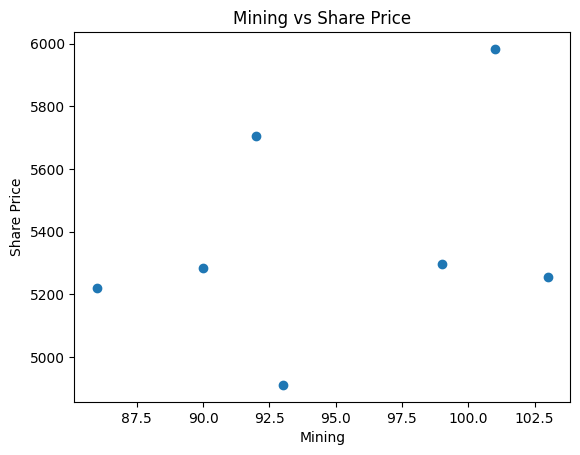

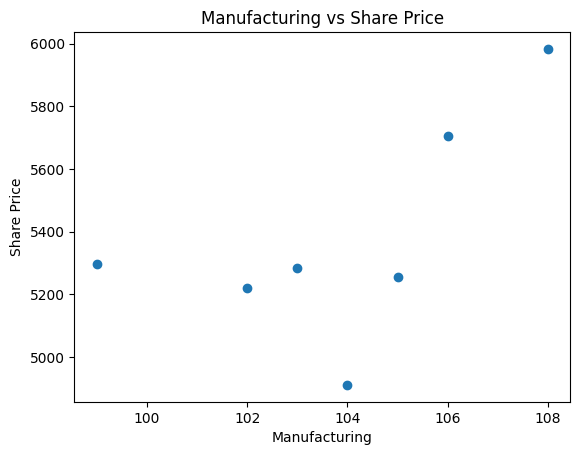

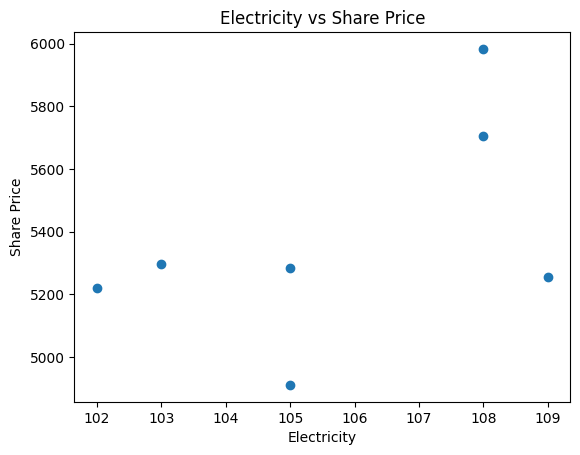

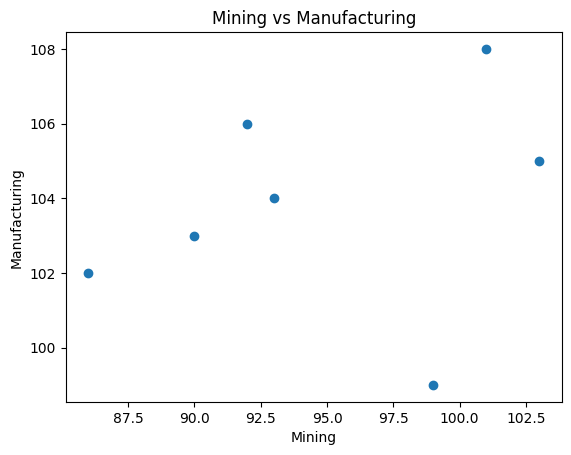

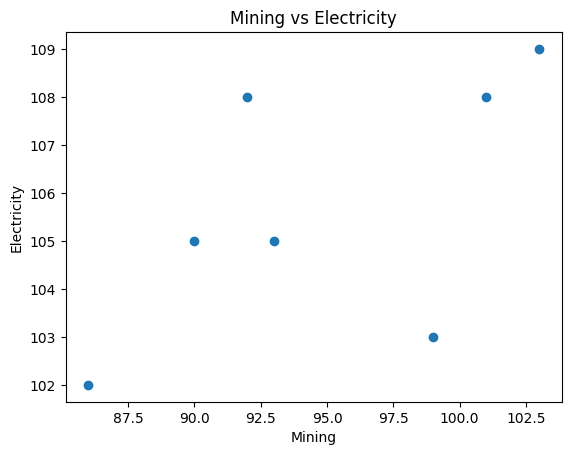

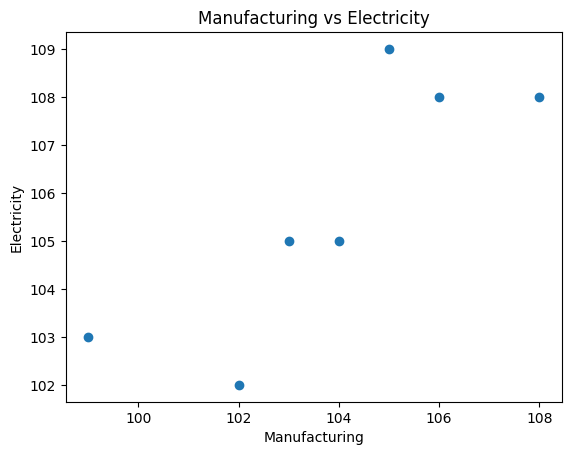

In [20]:
import matplotlib.pyplot as plt

# 1. Share Price vs Mining
plt.scatter(df_cleaned["Mining"], df_cleaned["Share Price"])
plt.xlabel("Mining")
plt.ylabel("Share Price")
plt.title("Mining vs Share Price")
plt.show()


# 2. Share Price vs Manufacturing
plt.scatter(df_cleaned["Manufacturing"], df_cleaned["Share Price"])
plt.xlabel("Manufacturing")
plt.ylabel("Share Price")
plt.title("Manufacturing vs Share Price")
plt.show()


# 3. Share Price vs Electricity
plt.scatter(df_cleaned["Electricity"], df_cleaned["Share Price"])
plt.xlabel("Electricity")
plt.ylabel("Share Price")
plt.title("Electricity vs Share Price")
plt.show()


# 4. Mining vs Manufacturing
plt.scatter(df_cleaned["Mining"], df_cleaned["Manufacturing"])
plt.xlabel("Mining")
plt.ylabel("Manufacturing")
plt.title("Mining vs Manufacturing")
plt.show()


# 5. Mining vs Electricity
plt.scatter(df_cleaned["Mining"], df_cleaned["Electricity"])
plt.xlabel("Mining")
plt.ylabel("Electricity")
plt.title("Mining vs Electricity")
plt.show()


# 6. Manufacturing vs Electricity
plt.scatter(df_cleaned["Manufacturing"], df_cleaned["Electricity"])
plt.xlabel("Manufacturing")
plt.ylabel("Electricity")
plt.title("Manufacturing vs Electricity")
plt.show()

In [21]:
from sklearn.linear_model import LinearRegression

# Independent variables (X) and dependent variable (Y)
X = df_cleaned[["Mining", "Manufacturing", "Electricity"]]
y = df_cleaned["Share Price"]

# Model
model = LinearRegression()
model.fit(X, y)

# Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -1800.642988293862
Coefficients: [ 16.60371868  96.50154219 -41.78782359]


In [22]:
# Example prediction
predicted_price = model.predict([[95, 104, 107]])
print("Predicted Share Price:", predicted_price)

Predicted Share Price: [5341.5735498]


C:\Users\Rajat Jain\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
